In [10]:
# --- Imports ---
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
from scipy.integrate import odeint
from scipy.stats.qmc import LatinHypercube

In [11]:
# --- Data Generation ---
g_const = 9.81
initial_state = [np.pi/4, 0.0]

def rhs(state, t, L, g):
    theta, theta_dot = state
    return [theta_dot, -(g / L) * np.sin(theta)]

def generate_trajectory(L, t_end, num_points):
    t_arr = np.linspace(0, t_end, num_points)
    states = odeint(rhs, initial_state, t_arr, args=(L, g_const))
    return t_arr.reshape(-1, 1), np.full_like(t_arr, L).reshape(-1, 1), states[:, 0:1]

# Time horizon to ensure multiple cycles
t_end = 10.0
resolution = 1000 # High resolution for the exact curves

# 1. Training Data (L bounds: [0.5, 2.0])
np.random.seed(42)
L_train_vals = [0.5, 0.875, 1.25, 1.625, 2.0]
X_train_list, theta_train_list = [], []

for L in L_train_vals:
    t_arr, L_arr, theta_arr = generate_trajectory(L, t_end, resolution)
    # Sample 40 sparse points across the 10 seconds for each length
    t_samp, L_samp, theta_samp = t_arr[0::25], L_arr[0::25], theta_arr[0::25]
    theta_samp += np.random.normal(0, 0.02, size=theta_samp.shape) # Add noise
    
    X_train_list.append(np.hstack([t_samp, L_samp]))
    theta_train_list.append(theta_samp)

X_train = np.vstack(X_train_list)
theta_train = jnp.array(np.vstack(theta_train_list))

# 2. Multiple Interpolations (Lengths inside [0.5, 2.0])
L_interp_vals = [0.7, 1.0, 1.5]
interp_data = [generate_trajectory(L, t_end, resolution) for L in L_interp_vals]

# 3. Multiple Extrapolations (Lengths outside [0.5, 2.0])
L_extrap_vals = [0.25, 2.5, 3.0]
extrap_data = [generate_trajectory(L, t_end, resolution) for L in L_extrap_vals]

# 4. Expanded Collocation Points Cloud
# We increase to 2000 points because the t and L domains are much larger now
lhs = LatinHypercube(d=2, seed=0)
samples = lhs.random(n=2000)
t_col = (0.0 + (t_end - 0.0) * samples[:, 0]).flatten()
L_col = (0.25 + (3.0 - 0.25) * samples[:, 1]).flatten()

In [12]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        X = jax.nn.tanh(jnp.dot(X, layer['W']) + layer['B'])
    return jnp.dot(X, last['W']) + last['B']

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

# --- CELL 4: LOSS FUNCTIONS ---
@jax.jit
def loss_DDNN(params, X, theta_true):
    theta_pred = NN(X, params)
    return jnp.mean((theta_true - theta_pred)**2)

@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.001 * physics_loss

Training started...
Training complete.
--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.7307 | PINN L2: 0.7433
L=1.00 | DDNN L2: 0.6585 | PINN L2: 0.6569
L=1.50 | DDNN L2: 0.5362 | PINN L2: 0.4993

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.0480 | PINN L2: 1.0311
L=2.50 | DDNN L2: 0.5701 | PINN L2: 0.3701
L=3.00 | DDNN L2: 0.9635 | PINN L2: 0.6936


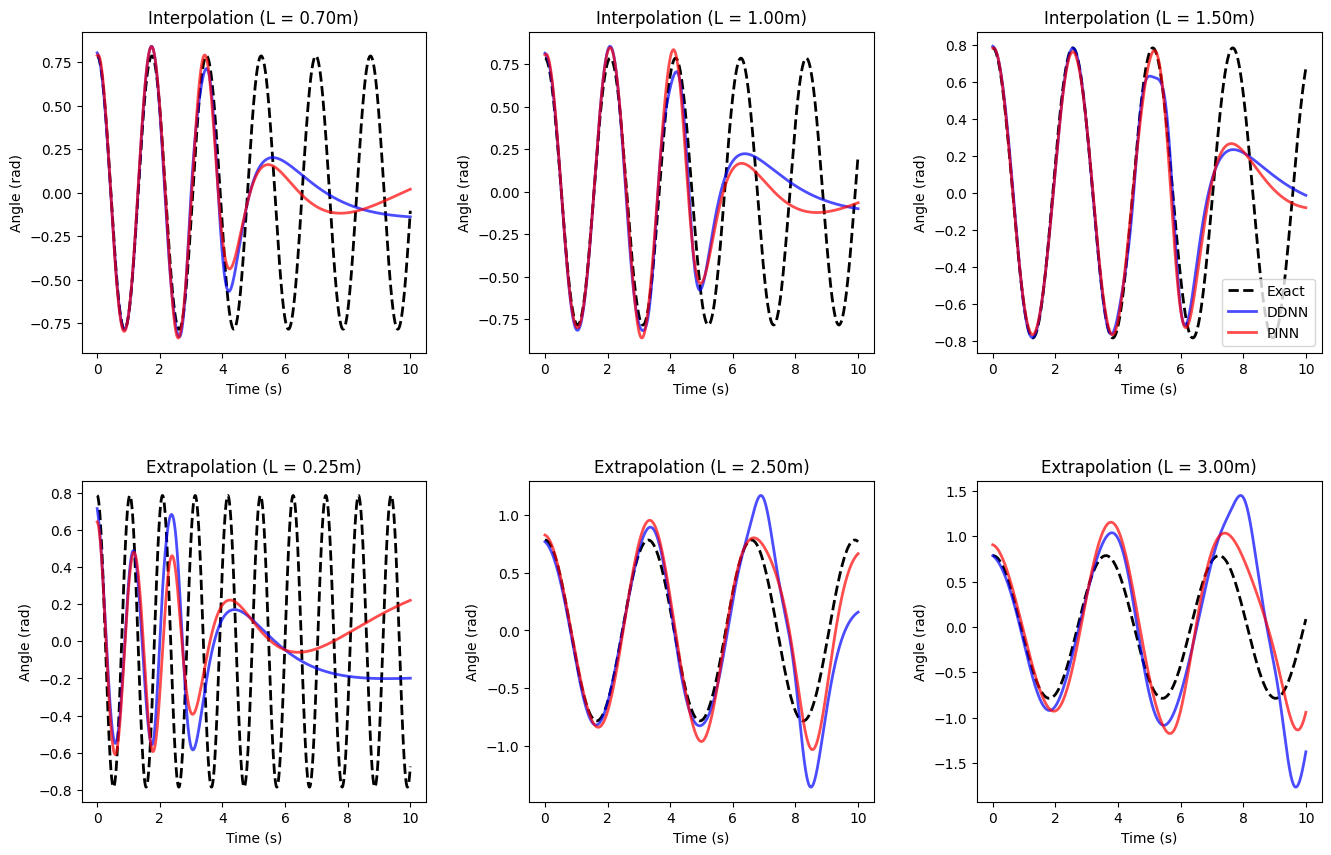

In [ ]:
# --- TRAINING LOOP 5000 Steps ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Multiple Interpolations (Top Row)
print("--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6842 | PINN L2: 0.7647
L=1.00 | DDNN L2: 0.6273 | PINN L2: 0.6647
L=1.50 | DDNN L2: 0.2611 | PINN L2: 0.4353

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.1253 | PINN L2: 1.0691
L=2.50 | DDNN L2: 0.5801 | PINN L2: 0.3379
L=3.00 | DDNN L2: 1.0319 | PINN L2: 0.6065


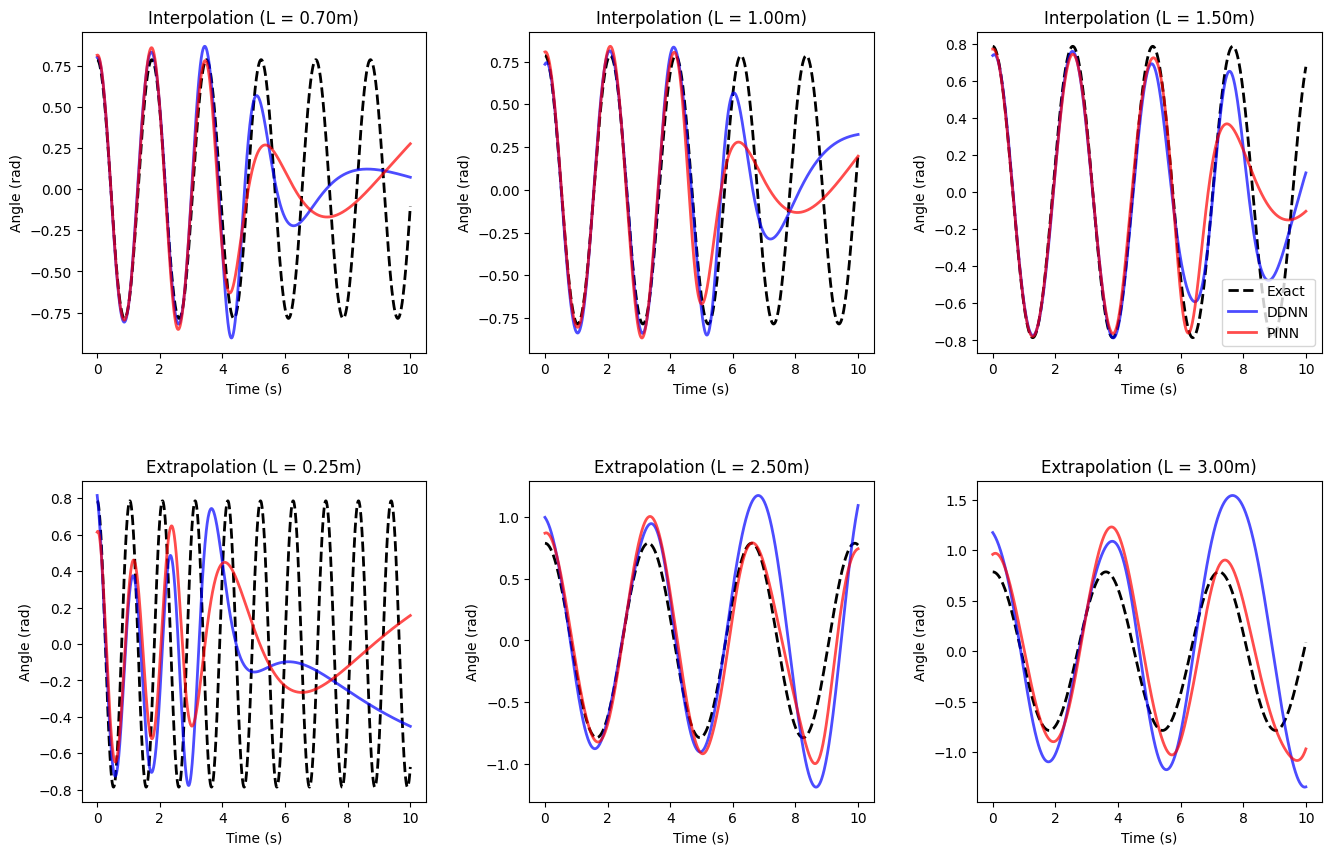

In [16]:
# --- TRAINING LOOP 10,000 Steps ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Multiple Interpolations (Top Row)
print("--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()